# New Zealand International Trade Data Analysis

## Project Overview

This notebook presents an exploratory analysis of New Zealand international trade data enriched with CPI information. The aim is to understand the structure of the dataset, inspect trade patterns over time, and identify relationships between key numeric variables.

## Background

This project is based on a broader trade analysis that originally used tools such as MS Access, Excel, Power BI, and DAX. The version in this repository focuses on a Python-based workflow that can be viewed directly on GitHub.

## Dataset

The analysis uses [`NZInternationalTradewithCPI.csv`](./NZInternationalTradewithCPI.csv), a combined dataset prepared from Stats NZ and external sources including OECD and IMF.

## Workflow

1. Load and inspect the dataset.
2. Clean the imported file and check data quality.
3. Review descriptive statistics and category structure.
4. Explore numeric relationships using correlation analysis.
5. Visualise distributions and time-based trade patterns.
6. Summarise insights from imports, exports, and year-based comparisons.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

csv_path = 'NZInternationalTradewithCPI.csv'
raw = pd.read_csv(csv_path)
df = pd.read_csv(csv_path)

df.head().T


,0,1,2,3,4
ID,1,2,3,4,5
Year,2015,2015,2015,2015,2015
Country_Code,AE,AF,AG,AI,AL
TradeID,2015AE,2015AF,2015AG,2015AI,2015AL
Country,United Arab Emirates,Afghanistan,Antigua and Barbuda,Anguilla,Albania
Continent,Asia,Asia,North America,North America,Europe
Annual_Exports,832994581,403739,2602815,83182,136189
Annual_Imports,425569309,105120,19446,192440,371606
Annual_CPI,97.521628,101.295751,96.561272,106.1275,92.435759
Annual_Trade,1258563890,508859,2622261,275622,507795


**Result, Interpretation and Insights**

The dataset loads successfully and the transposed preview makes it easier to inspect the available fields at a glance.

- The file contains trade, CPI, country, and continent information.
- The project is reproducible directly from the CSV stored in the repository.
- Starting with a visible data preview helps readers understand the dataset before moving into analysis.


## Data Cleaning and Structure

Before analysing the trade patterns, the imported file needs a quick cleaning pass and a datatype check.


In [2]:
# Drop empty helper columns carried over from the source file.
df = df.drop(['Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13'], axis=1)

df.head(20)


,ID,Year,Country_Code,TradeID,Country,Continent,Annual_Exports,Annual_Imports,Annual_CPI,Annual_Trade
0,1,2015,AE,2015AE,United Arab Emirates,Asia,832994581,425569309,97.521628,1258563890
1,2,2015,AF,2015AF,Afghanistan,Asia,403739,105120,101.295751,508859
2,3,2015,AG,2015AG,Antigua and Barbuda,North America,2602815,19446,96.561272,2622261
3,4,2015,AI,2015AI,Anguilla,North America,83182,192440,106.127500,275622
4,5,2015,AL,2015AL,Albania,Europe,136189,371606,92.435759,507795
5,6,2015,AM,2015AM,Armenia,Asia,15156903,84690,124.231344,15241593
6,7,2015,AO,2015AO,Angola,Africa,31797456,2671,31.105833,31800127
7,8,2015,AT,2015AT,Austria,Europe,21240817,190620522,92.479826,211861339
8,9,2015,AU,2015AU,Australia,Oceania,8339522914,5952382718,107.675000,14291905632
9,10,2015,AW,2015AW,Aruba,North America,991912,16741,93.729976,1008653


In [3]:
df.dtypes

ID                  int64
Year                int64
Country_Code       object
TradeID            object
Country            object
Continent          object
Annual_Exports      int64
Annual_Imports      int64
Annual_CPI        float64
Annual_Trade        int64
dtype: object

**Result, Interpretation and Insights**

The cleaning step removes unused placeholder columns from the CSV import, and the datatype output confirms how pandas is treating each field.

- Removing empty columns improves readability and avoids confusion later in the notebook.
- Checking data types helps confirm which fields are ready for numeric analysis and which remain categorical.
- This step gives readers confidence that the analysis is built on a tidy working table.


## Descriptive Statistics

Descriptive statistics provide a quick overview of the scale and spread of the numeric trade variables.


In [4]:
# Summary statistics for numeric columns, excluding ID and Year.
df_summary = df.loc[:, ~df.columns.isin(['ID', 'Year'])]
df_summary.describe()


,Annual_Exports,Annual_Imports,Annual_CPI,Annual_Trade
count,1.374000e+03,1.374000e+03,1374.000000,1.374000e+03
mean,3.195644e+08,3.401909e+08,246.344511,6.597553e+08
std,1.437361e+09,1.307970e+09,1059.930856,2.717947e+09
min,0.000000e+00,0.000000e+00,1.995910,1.019000e+03
25%,1.736079e+06,1.932455e+05,99.187944,3.478948e+06
50%,1.418290e+07,4.495162e+06,104.470833,3.023979e+07
75%,8.818652e+07,9.022933e+07,120.442917,2.117928e+08
max,2.013164e+10,1.816951e+10,16785.029010,3.830115e+10


**Result, Interpretation and Insights**

The summary statistics show the central tendency and range of the main numeric fields after excluding identifier-style columns.

- This view helps identify variation in imports, exports, and CPI values.
- It provides context for later charts by showing whether the data is tightly grouped or widely spread.
- Summary statistics are useful for spotting possible outliers or unusually large trade values.


## Categorical Distribution by Continent

This section checks how observations are distributed across continents and reviews grouped descriptive statistics.


In [5]:
# Review continent distribution and grouped descriptive statistics.
(df['Continent'].value_counts())

(df.groupby('Continent').describe().T)


Continent                   Africa          Asia        Europe  North America  \
ID             count  3.570000e+02  3.440000e+02  2.900000e+02   2.070000e+02   
               mean   7.031485e+02  6.866105e+02  6.876069e+02   6.504058e+02   
               std    3.966047e+02  3.954088e+02  3.965355e+02   4.003481e+02   
               min    7.000000e+00  1.000000e+00  5.000000e+00   3.000000e+00   
               25%    3.600000e+02  3.427500e+02  3.370000e+02   2.955000e+02   
               50%    6.990000e+02  6.785000e+02  6.825000e+02   6.240000e+02   
               75%    1.038000e+03  1.016250e+03  1.021750e+03   9.875000e+02   
               max    1.374000e+03  1.369000e+03  1.363000e+03   1.368000e+03   
Year           count  3.570000e+02  3.440000e+02  2.900000e+02   2.070000e+02   
               mean   2.018443e+03  2.018407e+03  2.018462e+03   2.018256e+03   
               std    2.287038e+00  2.283815e+00  2.293426e+00   2.297561e+00   
               min    2.015000e+03  2.015000e+03  2.015000e+03   2.015000e+03   
               25%    2.016000e+03  2.016000e+03  2.016000e+03   2.016000e+03   
               50%    2.018000e+03  2.018000e+03  2.018000e+03   2.018000e+03   
               75%    2.020000e+03  2.020000e+03  2.020000e+03   2.020000e+03   
               max    2.022000e+03  2.022000e+03  2.022000e+03   2.022000e+03   
Annual_Exports count  3.570000e+02  3.440000e+02  2.900000e+02   2.070000e+02   
               mean   3.801793e+07  7.087769e+08  1.448532e+08   2.900173e+08   
               std    1.018868e+08  2.341480e+09  3.024474e+08   1.185330e+09   
               min    0.000000e+00  0.000000e+00  5.928000e+03   0.000000e+00   
               25%    4.515940e+05  8.385619e+06  4.228625e+06   8.084375e+05   
               50%    2.648826e+06  5.319976e+07  2.123069e+07   4.447696e+06   
               75%    1.124362e+07  6.863309e+08  1.224879e+08   3.434276e+07   
               max    8.153127e+08  2.013164e+10  1.668955e+09   7.817719e+09   
Annual_Imports count  3.570000e+02  3.440000e+02  2.900000e+02   2.070000e+02   
               mean   7.133964e+06  7.344618e+08  3.146377e+08   2.756802e+08   
               std    2.546363e+07  2.093099e+09  5.780697e+08   1.155791e+09   
               min    0.000000e+00  1.500000e+01  8.595000e+03   0.000000e+00   
               25%    2.195400e+04  6.137430e+05  1.344287e+07   2.663050e+04   
               50%    2.882010e+05  1.938793e+07  8.004522e+07   8.563890e+05   
               75%    1.938417e+06  4.045713e+08  3.481753e+08   8.137668e+06   
               max    1.882243e+08  1.816951e+10  3.473777e+09   7.239157e+09   
Annual_CPI     count  3.570000e+02  3.440000e+02  2.900000e+02   2.070000e+02   
               mean   3.101589e+02  1.234819e+02  3.157658e+02   1.214092e+02   
               std    1.606168e+03  1.026321e+02  1.145752e+03   5.050356e+01   
               min    1.995910e+00  2.559904e+01  5.105220e+01   7.458489e+01   
               25%    9.449517e+01  9.758138e+01  1.002973e+02   1.002128e+02   
               50%    1.036500e+02  1.021282e+02  1.047896e+02   1.062350e+02   
               75%    1.203831e+02  1.197844e+02  1.241835e+02   1.165773e+02   
               max    1.678503e+04  1.401655e+03  8.515216e+03   3.904500e+02   
Annual_Trade   count  3.570000e+02  3.440000e+02  2.900000e+02   2.070000e+02   
               mean   4.515189e+07  1.443239e+09  4.594909e+08   5.656975e+08   
               std    1.110671e+08  4.395560e+09  8.309492e+08   2.336678e+09   
               min    1.019000e+03  7.262000e+03  1.970400e+04   2.276000e+03   
               25%    8.117050e+05  1.066045e+07  1.882384e+07   1.276362e+06   
               50%    4.011751e+06  9.898427e+07  1.100352e+08   5.332452e+06   
               75%    1.768116e+07  1.153121e+09  4.508741e+08   4.600101e+07   
               max    8.238164e+08  3.830115e+10  4.322555e+09   1.505688e+10   

Continent                  Oce

**Result, Interpretation and Insights**

The continent counts and grouped statistics show how the dataset is distributed geographically.

- Some continents contribute more observations than others, which can affect comparisons.
- Grouped statistics help reveal whether trade values differ across regions.
- This step adds geographic context before moving into numeric relationships and visual analysis.


## Correlation Analysis

Correlation analysis helps identify whether the main numeric variables move together.


In [6]:
# Pearson correlation for numeric variables.
df.corr(numeric_only=True)


,ID,Year,Annual_Exports,Annual_Imports,Annual_CPI,Annual_Trade
ID,1.000000,0.991975,0.025631,0.035969,0.049979,0.030864
Year,0.991975,1.000000,0.035538,0.045705,0.053651,0.040789
Annual_Exports,0.025631,0.035538,1.000000,0.960213,-0.023781,0.990928
Annual_Imports,0.035969,0.045705,0.960213,1.000000,-0.028028,0.989034
Annual_CPI,0.049979,0.053651,-0.023781,-0.028028,1.000000,-0.026064
Annual_Trade,0.030864,0.040789,0.990928,0.989034,-0.026064,1.000000


In [7]:
# Spearman correlation with gradient styling for easier interpretation.
(df
 .corr(method='spearman', numeric_only=True)
 .style
 .background_gradient(cmap='RdBu', vmin=-1, vmax=1)
)


,ID,Year,Annual_Exports,Annual_Imports,Annual_CPI,Annual_Trade
ID,1.000000,0.992119,0.022583,0.069152,0.401651,0.043267
Year,0.992119,1.000000,0.018362,0.071126,0.395086,0.042133
Annual_Exports,0.022583,0.018362,1.000000,0.707960,0.069365,0.937973
Annual_Imports,0.069152,0.071126,0.707960,1.000000,0.047305,0.860360
Annual_CPI,0.401651,0.395086,0.069365,0.047305,1.000000,0.095416
Annual_Trade,0.043267,0.042133,0.937973,0.860360,0.095416,1.000000


In [8]:
# Compare Year and Annual CPI using Pearson and Spearman correlation.
df['Year'].corr(df['Annual_CPI'])
df['Year'].corr(df['Annual_CPI'], method='spearman')


0.3950861733497487

**Result, Interpretation and Insights**

The Pearson and Spearman outputs provide both linear and rank-based views of the relationships in the data.

- Pearson correlation is useful for measuring straight-line relationships between numeric variables.
- Spearman correlation helps confirm whether the same pattern holds in ranked form.
- Comparing Year with Annual CPI is especially useful for checking whether CPI tends to move upward over time.
- These results help identify which variables may be associated strongly enough to matter in later modelling or explanation.


## Distribution of Imports and Exports

Histograms help show the overall spread of New Zealand's import and export values.


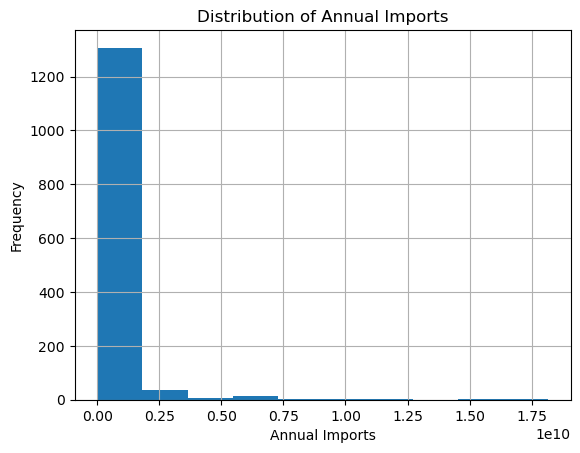

In [9]:
# Histogram of annual imports.
(df
 .Annual_Imports
 .hist(bins=10)
)
plt.title('Distribution of Annual Imports')
plt.xlabel('Annual Imports')
plt.ylabel('Frequency')
plt.show()


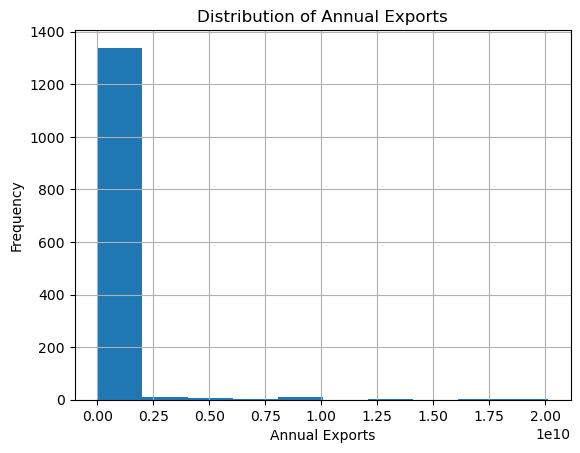

In [10]:
# Histogram of annual exports.
(df
 .Annual_Exports
 .hist(bins=10)
)
plt.title('Distribution of Annual Exports')
plt.xlabel('Annual Exports')
plt.ylabel('Frequency')
plt.show()


**Result, Interpretation and Insights**

The histograms show how annual imports and exports are distributed across the dataset.

- The distribution shape helps indicate whether trade values are symmetric or skewed.
- Skewed distributions may suggest that a small number of observations account for unusually high trade volumes.
- Looking at both imports and exports side by side helps compare whether they behave similarly or differently.


## Trade Trends Over Time

Scatter and density plots make it easier to inspect how trade values change across years.


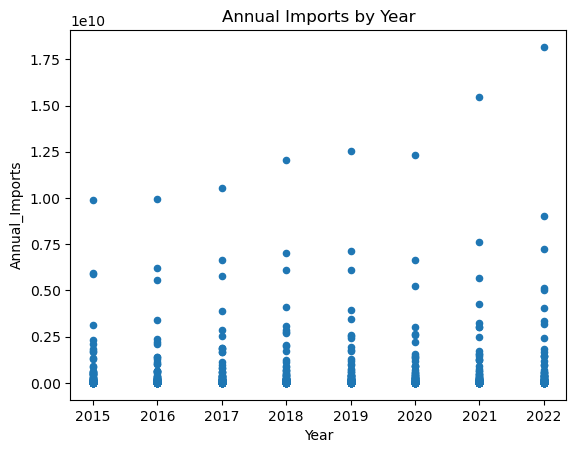

In [11]:
# Scatter plot of annual imports over time.
(df
 .plot
 .scatter(x='Year', y='Annual_Imports')
)
plt.title('Annual Imports by Year')
plt.show()


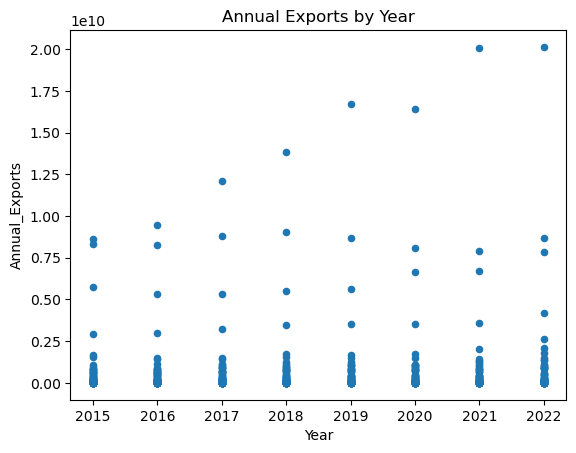

In [12]:
# Scatter plot of annual exports over time.
(df
 .plot
 .scatter(x='Year', y='Annual_Exports')
)
plt.title('Annual Exports by Year')
plt.show()


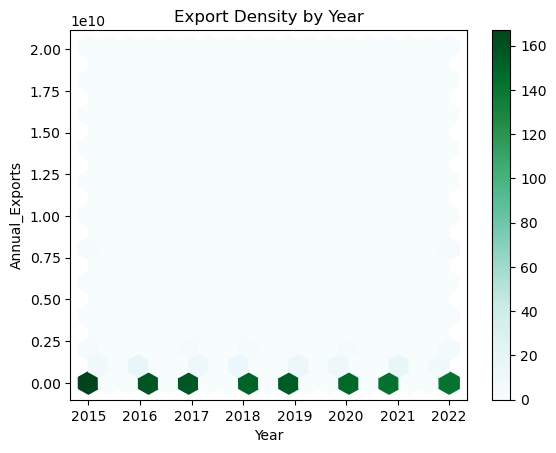

In [13]:
# Hexbin plot to show export density over time.
(df
 .plot
 .hexbin(x='Year', y='Annual_Exports', alpha=1, gridsize=18)
)
plt.title('Export Density by Year')
plt.show()


**Result, Interpretation and Insights**

The time-based charts show how annual imports and exports vary across the observed years, while the hexbin plot highlights where export values are most concentrated.

- Scatter plots reveal the overall spread and potential trend direction over time.
- The export density view is helpful when many points overlap and simple scatter plots become crowded.
- These charts support a more visual understanding of whether trade values are stable, rising, or more volatile across the years.


## Year-by-Year Distribution Analysis

Boxplots help compare how the distribution of imports and exports changes from year to year.


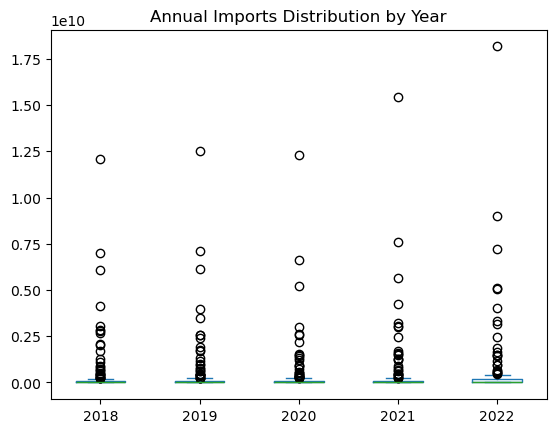

In [14]:
# Boxplots of annual imports for recent years.
(df
 .pivot(columns='Year', values='Annual_Imports')
 .apply(lambda ser: ser[~ser.isna()].reset_index(drop=True))
 .loc[:, [2018, 2019, 2020, 2021, 2022]]
 .plot.box()
)
plt.title('Annual Imports Distribution by Year')
plt.show()


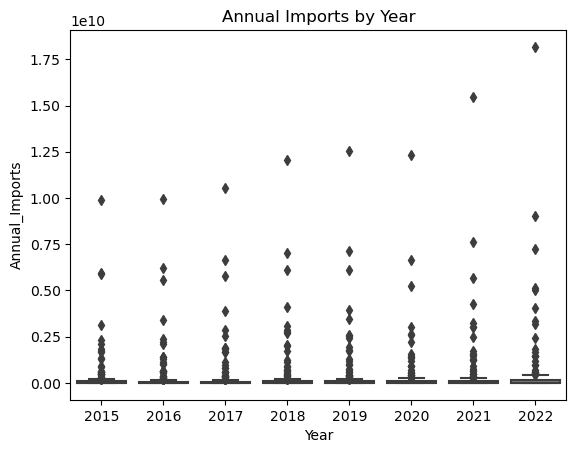

In [15]:
# Seaborn boxplot for annual imports.
sns.boxplot(data=df, x='Year', y='Annual_Imports')
plt.title('Annual Imports by Year')
plt.show()


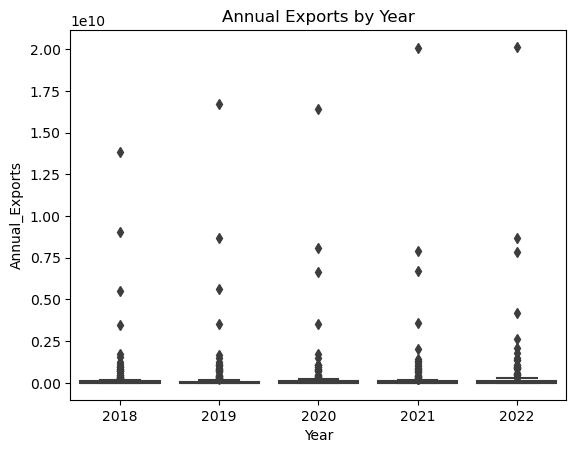

In [16]:
# Seaborn boxplot for annual exports.
sns.boxplot(data=df, x='Year', y='Annual_Exports', order=[2018, 2019, 2020, 2021, 2022])
plt.title('Annual Exports by Year')
plt.show()


**Result, Interpretation and Insights**

The boxplots show the spread, median, and potential outliers in trade values by year.

- They make it easier to compare variability across years than summary statistics alone.
- If the boxes shift upward or downward, that suggests a change in typical trade values over time.
- Outliers are important because they may reflect unusually strong or weak trading periods.


## Cross-Tabulation by Continent and Year

A crosstab gives a simple way to inspect how observations are distributed by both continent and year.


In [17]:
# Crosstab of continent by year with heatmap-style formatting.
(pd.crosstab(index=df['Continent'], columns=df['Year'])
 .style
 .background_gradient(cmap='viridis', axis=None)
)


Year,2015,2016,2017,2018,2019,2020,2021,2022
Continent,,,,,,,,
Africa,46,46,45,45,45,44,44,42
Asia,45,45,44,44,44,41,41,40
Europe,37,37,37,36,36,36,36,35
North America,30,30,27,26,26,23,22,23
Oceania,12,12,11,11,11,11,11,10
South America,11,11,11,10,11,11,11,11


**Result, Interpretation and Insights**

The crosstab and colour gradient highlight where observations are concentrated across continents and years.

- This helps identify whether the dataset is balanced or whether some years and continents dominate the sample.
- A more uneven pattern may affect how confidently some year-by-region comparisons can be made.
- This section supports the reader's understanding of the dataset structure, not just the trade values themselves.


## Time-Series Analysis

This section adds a yearly time-series view of imports, exports, and CPI. It supports the broader project paper by showing how the average trade indicators move across time in the Python workflow.


,Annual_Imports,Annual_Exports,Annual_CPI
Year,,,
2015,2.701266e+08,2.569127e+08,171.704374
2016,2.667858e+08,2.540607e+08,202.572094
2017,3.036518e+08,2.910670e+08,193.158915
2018,3.472728e+08,3.144847e+08,217.450950
2019,3.503004e+08,3.285245e+08,254.963308
2020,3.210048e+08,3.382306e+08,289.010368
2021,3.936712e+08,3.653671e+08,313.960826
2022,4.877431e+08,4.242275e+08,345.596490


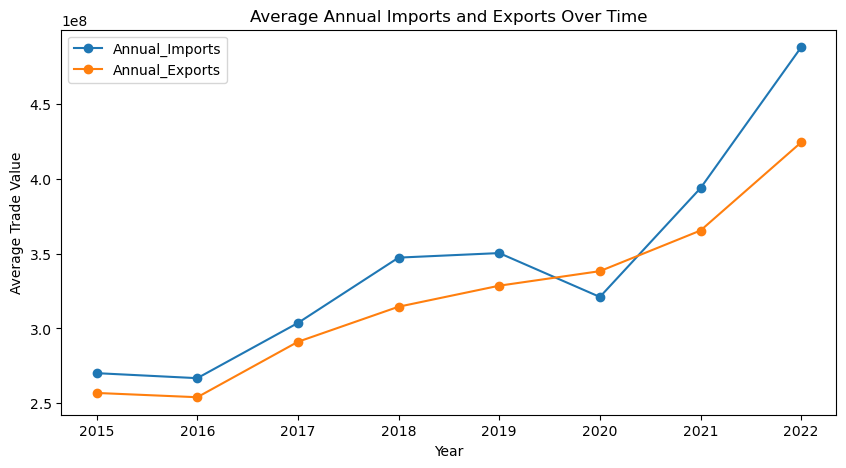

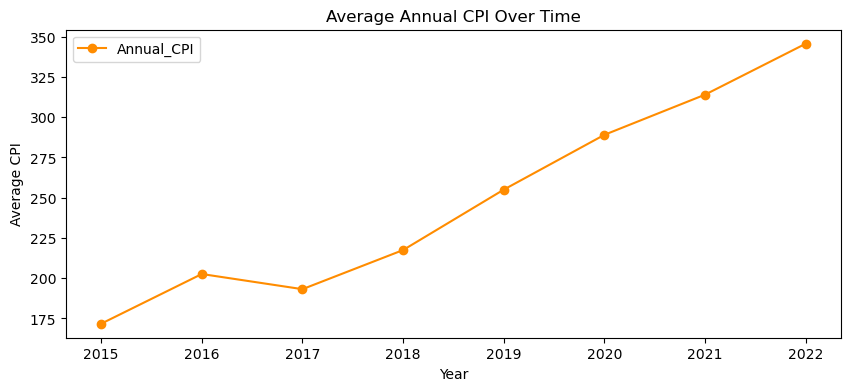

In [18]:
# Yearly time-series summary for imports, exports, and CPI.
yearly_trade = (df
    .groupby('Year')[['Annual_Imports', 'Annual_Exports', 'Annual_CPI']]
    .mean()
    .sort_index()
)

display(yearly_trade)

ax = yearly_trade[['Annual_Imports', 'Annual_Exports']].plot(marker='o', figsize=(10, 5))
ax.set_title('Average Annual Imports and Exports Over Time')
ax.set_ylabel('Average Trade Value')
ax.set_xlabel('Year')
plt.show()

ax = yearly_trade[['Annual_CPI']].plot(marker='o', color='darkorange', figsize=(10, 4))
ax.set_title('Average Annual CPI Over Time')
ax.set_ylabel('Average CPI')
ax.set_xlabel('Year')
plt.show()


**Result, Interpretation and Insights**

The yearly summary table and line charts show how the average import, export, and CPI values move from 2015 to 2022.

- Average imports and exports both trend upward across the observed period, although the pace of change is not identical each year.
- Imports dip slightly around 2020 before rising strongly through 2021 and 2022.
- Exports continue to increase over time and show a clear lift in the later years of the dataset.
- CPI also rises steadily across the period, suggesting an inflationary backdrop that should be kept in mind when interpreting nominal trade values.
- This time-series view strengthens the project by moving beyond static distributions and showing how trade indicators evolve over time.


## Final Summary

This notebook shows a complete exploratory workflow for New Zealand international trade data using Python.

### Overall Insights

- The dataset combines trade and CPI information in a format suitable for exploratory analysis.
- Cleaning and datatype checks are essential first steps before interpreting results.
- Correlation analysis helps reveal relationships between key numeric variables.
- Histograms, scatter plots, density plots, boxplots, and time-series charts each add a different perspective on how imports and exports behave.
- Cross-tabulation provides additional context about how the observations are distributed across regions and years.
- Time-series analysis makes the year-to-year movement in trade values easier to interpret in a business context.

Together, these steps turn the notebook into a readable project document that explains not only the code, but also what the results mean.
